In [3]:
import pandas as pd
df = pd.read_csv("../data/SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [3]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# category-wise sales

category_sales = df.groupby("Category") ["Sales"].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [ ]:
# total sales

total_sales = round(df["Sales"].sum(), 2)
print(total_sales)

2297200.86


In [8]:
# total profit

total_profit = round(df["Profit"].sum(), 2)
print(total_profit)

286397.02


In [11]:
# top 10 state by sales

top_state = (
        df.groupby("State")["Sales"].sum()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
)
print(top_state)

State
California      457687.63
New York        310876.27
Texas           170188.05
Washington      138641.27
Pennsylvania    116511.91
Florida          89473.71
Illinois         80166.10
Ohio             78258.14
Michigan         76269.61
Virginia         70636.72
Name: Sales, dtype: float64


In [ ]:
# find the most profitable category

category_sales = df.groupby("Category") ["Sales"].sum().head(1)
print(category_sales)

Category
Furniture    741999.7953
Name: Sales, dtype: float64


In [13]:
# find category with high sales but low profit
category_ana = (
    df.groupby("Category")[["Sales","Profit"]].sum().round(2)
)
analysis= category_ana [
    (category_ana["Sales"] > 50000) & (category_ana["Profit"] < 50000)
]
print(analysis)

              Sales    Profit
Category                     
Furniture  741999.8  18451.27


In [17]:
# analyze whether higher discounts increase sales but reduce profit
analysis = (
    df.groupby("Category")
    .agg({
        "Discount":"mean",
        "Sales":"sum",
        "Profit":"sum"
    })
    .round(2)
)
print(analysis)

                 Discount      Sales     Profit
Category                                       
Furniture            0.17  741999.80   18451.27
Office Supplies      0.16  719047.03  122490.80
Technology           0.13  836154.03  145454.95


In [18]:
# profit margin for rach category

profit_margin = (
    df.groupby("Category")[["Sales","Profit"]].sum()
)
profit_margin["Profit_Margin"] = round(
    (profit_margin["Profit"]/ profit_margin["Sales"]) * 100, 2)

print(profit_margin)

                       Sales       Profit  Profit_Margin
Category                                                
Furniture        741999.7953   18451.2728           2.49
Office Supplies  719047.0320  122490.8008          17.04
Technology       836154.0330  145454.9481          17.40


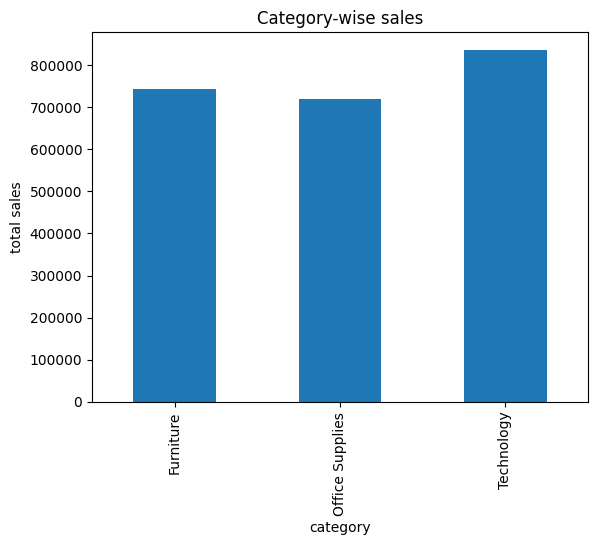

In [20]:
# bar chart for category-wise sales
import matplotlib.pyplot as plt

category_sales = (
    df.groupby("Category")["Sales"].sum().round(2)
)
category_sales.plot(kind="bar")
plt.title("Category-wise sales")
plt.xlabel("category")
plt.ylabel("total sales")
plt.show()

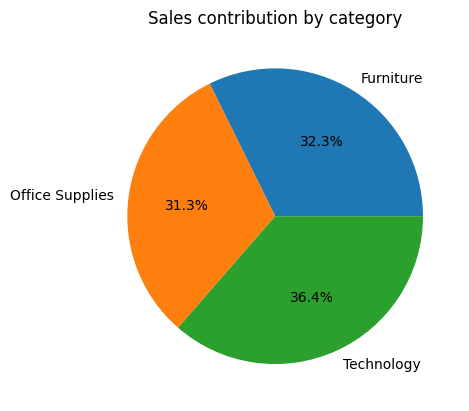

In [24]:
# pie chart for sales contribution by category
category_sales = (
    df.groupby("Category")["Sales"].sum().round(2)
)
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%"
)
plt.title("Sales contribution by category")
plt.show()

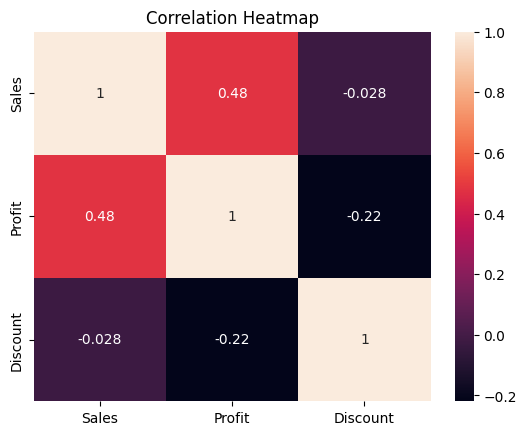

In [ ]:
# heatmap showing correlation between sales, profit, discount
import seaborn as sns
import matplotlib.pyplot as plt


correlation = df[["Sales", "Profit", "Discount"]].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()


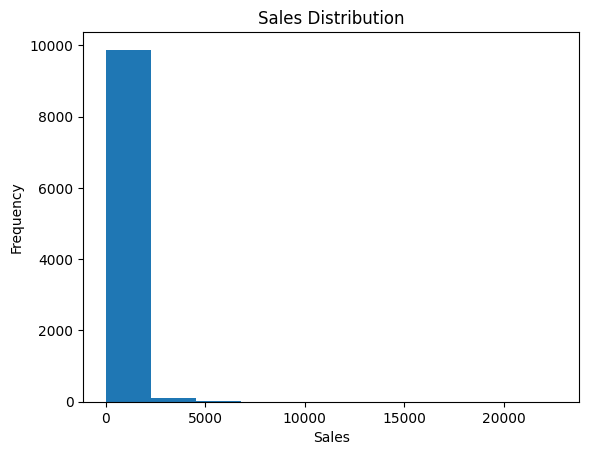

In [5]:
# histogram for sales distribution

plt.hist(df["Sales"])

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()


In [6]:
# cumulative sales using cumulative sum

df["Cumulative_Sales"] = df["Sales"].cumsum()

print(df[["Sales", "Cumulative_Sales"]])


         Sales  Cumulative_Sales
0     261.9600      2.619600e+02
1     731.9400      9.939000e+02
2      14.6200      1.008520e+03
3     957.5775      1.966098e+03
4      22.3680      1.988466e+03
...        ...               ...
9989   25.2480      2.296578e+06
9990   91.9600      2.296670e+06
9991  258.5760      2.296928e+06
9992   29.6000      2.296958e+06
9993  243.1600      2.297201e+06

[9994 rows x 2 columns]


In [7]:
# Rank categories based on total sales

category_rank = (
    df.groupby("Category")["Sales"]
    .sum()
    .rank(ascending=False)
)

print(category_rank)

Category
Furniture          2.0
Office Supplies    3.0
Technology         1.0
Name: Sales, dtype: float64


In [11]:
# Identify loss-making categories or sub-categories 

loss_categories = (
    df.groupby("Category")["Profit"]
    .sum()
)

loss_categories = loss_categories[loss_categories < 0]

print(loss_categories)


Series([], Name: Profit, dtype: float64)


In [10]:
# Sub-category-wise Loss

loss_subcategories = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
)

loss_subcategories = loss_subcategories[loss_subcategories < 0]

print(loss_subcategories)

Sub-Category
Bookcases    -3472.5560
Supplies     -1189.0995
Tables      -17725.4811
Name: Profit, dtype: float64


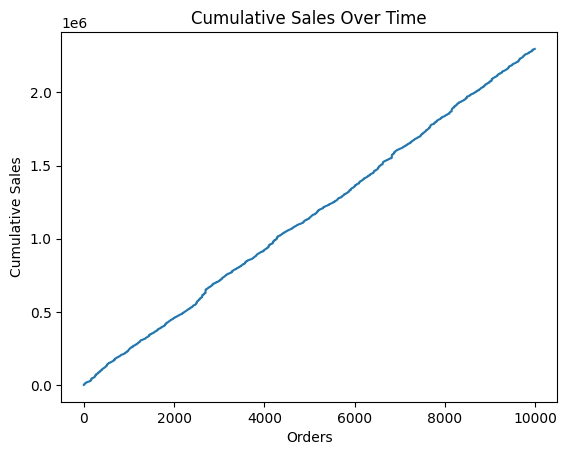

In [12]:
# line chart for cumulative sales

df["Cumulative_Sales"] = df["Sales"].cumsum()

plt.plot(df["Cumulative_Sales"])

plt.title("Cumulative Sales Over Time")
plt.xlabel("Orders")
plt.ylabel("Cumulative Sales")

plt.show()